In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Regularization
    Add somting extra to reduce the tentancy of overfitting

- **Types of Regularization**
  1. Ridge (L2)
  2. LASSO (L1)
  3. ElasticNet

# 1) Ridge (L2) Regularization
    In case of Linear Regresion
        If the slope/cofficent are too heigh then it results to over-fitting
        &
        If slope/cofficent are too low then it results to under-fitting

    In case of Ridge (L2) Regularization
        loss (f) = sigma(Y - Y_hat) + λ(sigma(m^2))
            where,
                λ can be 1 to +infinity

    (Because it has no potential harm, it is generally used in all algorithms.)

- **Key Points Ridge Regression**

        L = sigma(Y - Y_hat) + λ*(sigma(β^2))           ;            λ*(sigma(β^2)) is shrinkage coefficent
  1) **How the coefficient get efficted**

            If increases 0 -> +infinity
                coefficent shrink (close to '0' but not '0')
  2) **Higher coefficient values are impocted more**

            If β1=1000, β2=10, β3=1 and we increase the value of 'λ' then the greater the β value is the faster it will shrink
                That's Δβ1 > Δβ2 > Δβ3 where λ -> 1 to +infinity
  3) **Impact on Bias Variance Tradeoff**
     - If λ is too less

                Bias (dicrease) & variance (increase)
     - If λ is too heigh

                Bias (increase) & Variance (dicrease)
  4) **Impact on Loss function**

            uplift & moves towords the 0
                not exectly 0 but close to 0

- **Practical Tip**

        Use only when tere are more the 2 Dimensionality in the dataset

In [3]:
X = np.arange(10).reshape(10,1)
delta = np.random.uniform(0,100,size=(10,1))

y = 7*X + delta

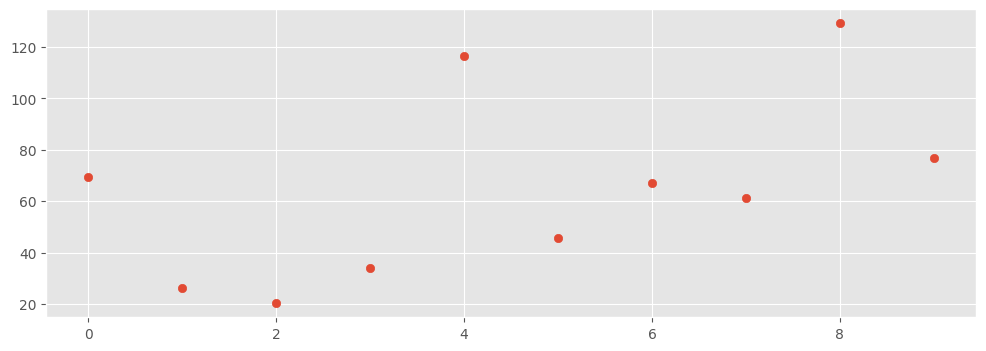

In [4]:
plt.figure(figsize=(12,4))

plt.scatter(X.ravel(), y.ravel())

plt.show()

In [5]:
idxs = np.where(X<=2)
X_train = np.random.choice(X[idxs], size=3, replace=False).reshape(3,1)
y_train = y[np.where(X == X_train.ravel())[0]].reshape(3,1)

In [6]:
X_test = np.delete(X,np.where(X == X_train.ravel())[0]).reshape(X.shape[0] - 3, 1)
y_test = np.delete(y,np.where(X == X_train.ravel())[0]).reshape(y.shape[0] - 3, 1)

## Model Perfomance Without Ridge Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X.reshape(X.shape[0],1))

mean_squared_error(y_pred=y_pred, y_true=y)

5359.283680866179

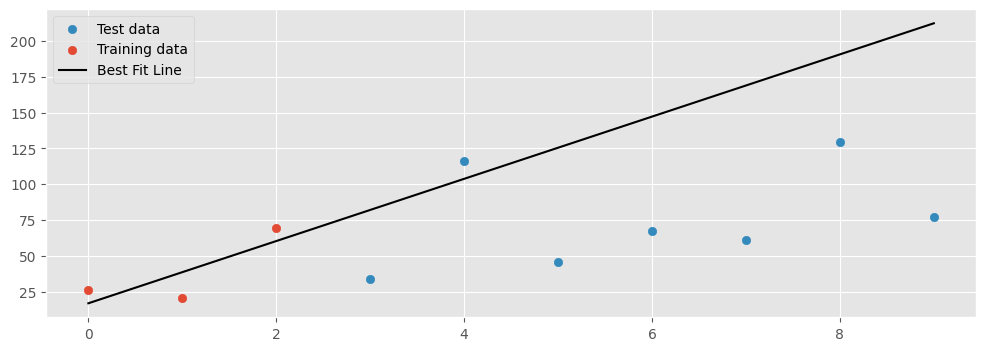

In [8]:
plt.figure(figsize=(12,4))

plt.scatter(X_test.ravel(), y_test.ravel(), color='C1', label='Test data')
plt.scatter(X_train.ravel(), y_train.ravel(), color='C0', label='Training data')
sns.lineplot(x=X.ravel(),y=y_pred.ravel(), color=(0,0,0,1), label='Best Fit Line')

plt.legend()
plt.show()

## Model Perfomance With Ridge Regression

In [9]:
rg = Ridge(alpha=200)
rg.fit(X_train,y_train)
y_pred = rg.predict(X.reshape(X.shape[0],1))

mean_squared_error(y_pred=y_pred, y_true=y), rg.coef_, rg.intercept_

(1800.6203520052331, array([0.21521287]), array([38.37087142]))

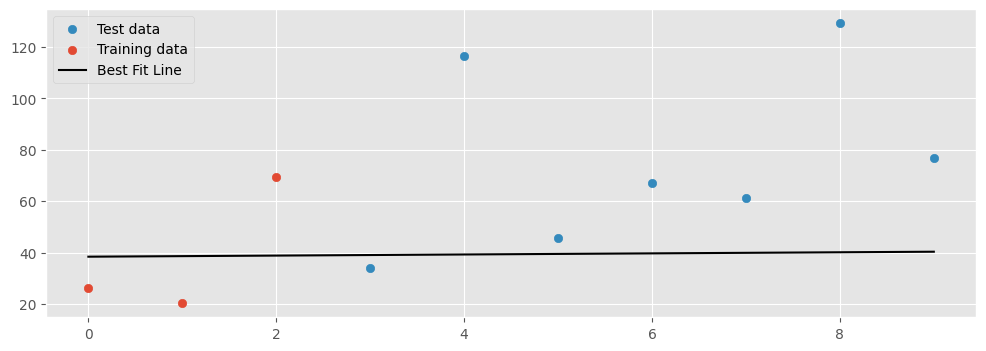

In [10]:
plt.figure(figsize=(12,4))

plt.scatter(X_test.ravel(), y_test.ravel(), color='C1', label='Test data')
plt.scatter(X_train.ravel(), y_train.ravel(), color='C0', label='Training data')
sns.lineplot(x=X.ravel(),y=y_pred.ravel(), color=(0,0,0,1), label='Best Fit Line')

plt.legend()
plt.show()

## Mathematical Intuition Of Ridge Regression (2D)

In [11]:
class MyRidge_2D:
    def __init__(self,lambda_ = 1):
        self.lambda_ = lambda_
        self.coef_ = None
        self.intercept = 1

    def fit(self, X, y):
        num = ((y - y.mean()).T).dot(X - X.mean())
        den = np.sum((X - X.mean())**2) + self.lambda_
        self.coef_ = num/den
        self.intercept = y.mean() - (self.coef_*X.mean())

    def predict(self, X):
        return (self.coef_*X) + self.intercept

In [12]:
Myrg = MyRidge_2D(lambda_=200)
Myrg.fit(X_train,y_train)

y_pred = Myrg.predict(X.reshape(X.shape[0],1))

mean_squared_error(y_pred=y_pred, y_true=y), Myrg.coef_, Myrg.intercept

(1800.6203520052331, array([[0.21521287]]), array([[38.37087142]]))

## Mathematical Intuition Of Ridge Regression (ND)

In [13]:
class MyRidge_ND:
    def __init__(self,lambda_ = 1):
        self.lambda_ = lambda_
        self.coef_ = None
        self.intercept = 1

    def fit(self, X, y):
        X_ = np.insert(X,0,1,axis=1)
        I = np.identity(X_.shape[1])
        I[0,0] = 0
        bita = np.linalg.inv(X_.T.dot(X_) + self.lambda_*I).dot(X_.T).dot(y)
        self.coef_ = bita[1:]
        self.intercept = bita[0]

    def predict(self, X):
        return (X.dot(self.coef_)) + self.intercept

In [14]:
Myrg = MyRidge_ND(lambda_=200)
Myrg.fit(X_train,y_train)

y_pred = Myrg.predict(X.reshape(X.shape[0],1))

mean_squared_error(y_pred=y_pred, y_true=y), Myrg.coef_, Myrg.intercept

(1800.6203520052331, array([[0.21521287]]), array([38.37087142]))

## Ridge Regression using Gradient Descent (ND)

In [15]:
X,y = load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.2)
X_train.shape, y_train.shape

((88, 10), (88,))

In [16]:
rg = SGDRegressor(penalty='l2',max_iter=500,eta0=.01,learning_rate='constant',alpha=0.01)
rg.fit(X_train,y_train)

y_pred = rg.predict(X_test)
r2_score(y_pred=y_pred, y_true=y_test), rg.coef_, rg.intercept_

(0.2954164056551458,
 array([ 57.92288804,   1.15298832, 158.28599374,  88.23609875,
         40.97183148,  36.79422274, -74.35689496,  91.93570391,
        110.53989166,  95.94827412]),
 array([152.61473063]))

In [17]:
class MyRidge_ND_GD:
    def __init__(self,lambda_ = 1, batch_size=10, epoch=100, lr=0.01):
        self.lambda_ = lambda_
        self.batch_size = batch_size
        self.epoch = epoch
        self.lr = lr
        self.coef_ = None
        self.intercept = None

    def fit(self, X, y):
        X = np.insert(X,0,1, axis=1)
        Bita = np.ones(shape=(X.shape[1],))
        Bita[0] = 0
        for i in range(self.epoch):
            for j in range(0,int(X.shape[0]/self.batch_size)):
                idxs = np.random.choice(range(0,X.shape[0]), size=self.batch_size, replace=False)
                b_derv = (X[idxs].T.dot(X[idxs]).dot(Bita)) - (X[idxs].T.dot(y[idxs])) + (self.lambda_*Bita)
                Bita -= (self.lr*b_derv)
        self.intercept = Bita[0]
        self.coef_ = Bita[1:]

    def predict(self, X):
        return (X.dot(self.coef_)) + self.intercept

In [18]:
Myrg = MyRidge_ND_GD(lambda_=0.01, batch_size=int(1), lr=.01, epoch=500)
Myrg.fit(X_train,y_train)

y_pred = Myrg.predict(X_test)
r2_score(y_pred=y_pred, y_true=y_test), Myrg.coef_, Myrg.intercept

(0.28238657274556633,
 array([ 59.12958557,  -3.75824118, 173.47520233,  93.7663241 ,
         37.43694282,  34.65694258, -79.29885027,  94.22477586,
        115.92321384, 101.52976493]),
 np.float64(140.13292033397587))

## Impact on Coefficents

In [19]:
delta = [0.001,0.01,0.1,1,10,100,1000]
df = pd.DataFrame(columns=['β1','β2','β3','β4','β5','β6','β7','β8','β9','β10'])
for i in delta:
    rg = Ridge(alpha=i)
    rg.fit(X_train,y_train)
    df.loc[i] = rg.coef_
df

,β1,β2,β3,β4,β5,β6,β7,β8,β9,β10
0.001,210.366010,-146.212915,532.444514,247.568237,-1237.385260,848.316569,354.797391,411.487922,654.189782,153.630933
0.010,197.032032,-142.816806,535.375395,230.047684,-334.854152,199.815587,-94.011827,206.919673,335.639462,156.003811
0.100,140.651202,-70.735094,427.929777,193.521421,-22.033354,27.749597,-158.995573,155.939889,224.170638,167.605507
1.000,57.467799,-0.498051,159.300109,87.452177,37.435728,34.002699,-73.242299,89.119423,108.744067,94.116715
10.000,9.525366,1.242392,23.810719,13.979016,8.420239,7.492842,-12.039771,15.858662,18.107596,15.758084
100.000,1.022049,0.149144,2.516421,1.489982,0.932026,0.829503,-1.288881,1.714627,1.941125,1.688655
1000.000,0.102958,0.015185,0.253097,0.149991,0.094183,0.083826,-0.129806,0.172859,0.195522,0.170083


# LASSO (L1) Regularization

    In case of Ridge (L2) Regularization
    loss (f) = sigma(Y - Y_hat) + λ(sigma(|β|))
        where,
            λ can be 1 to +infinity
- **Practical Tip**

        β can be reduced to 0
           There for it can be use for feature selection
- **Why Lasso is spars but not Ridge Regression**

        Because in Lasso Loss function derivative "λ" get adjusted with the numirater where as in Ridge Loss function derivative "λ" addid with dinominater, for λ -> 0 to +infinity

In [20]:
X = np.arange(10).reshape(10,1)
delta = np.random.uniform(0,100,size=(10,1))

y = 7*X + delta

In [21]:
idxs = np.where(X<=2)
X_train = np.random.choice(X[idxs], size=3, replace=False).reshape(3,1)
y_train = y[np.where(X == X_train.ravel())[0]].reshape(3,1)
X_test = np.delete(X,np.where(X == X_train.ravel())[0]).reshape(X.shape[0] - 3, 1)
y_test = np.delete(y,np.where(X == X_train.ravel())[0]).reshape(y.shape[0] - 3, 1)

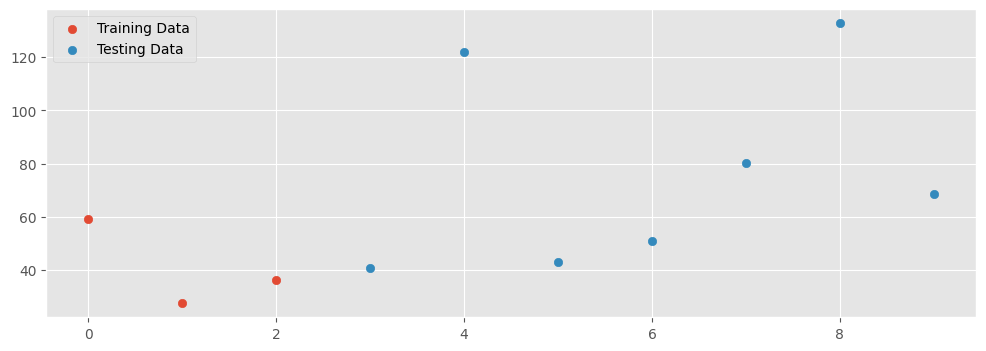

In [22]:
plt.figure(figsize=(12,4))

plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data', color='C0')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Testing Data', color='C1')

plt.legend()
plt.show()

In [23]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_ls = lr.predict(X)

In [24]:
preds:dict = {}
delta = [0.001,0.01,0.1,1,10,100]

for i in delta:
    lso = Lasso(alpha=i)
    lso.fit(X_train,y_train)
    y_pred = lso.predict(X)
    preds[f'Lambda {i}'] = y_pred

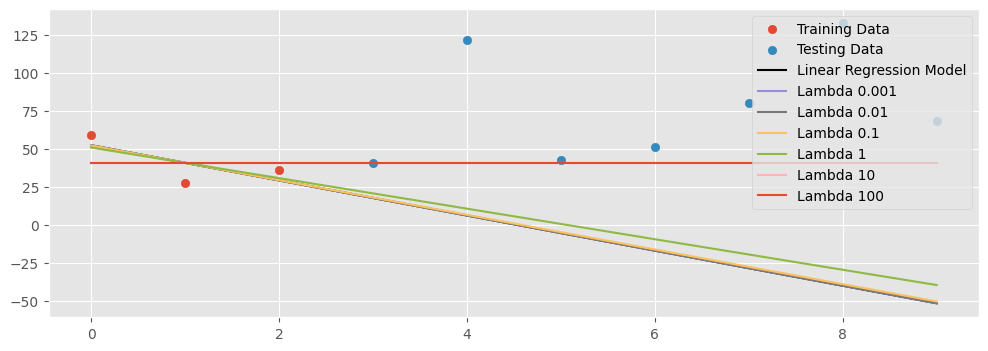

In [25]:
plt.figure(figsize=(12,4))

plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data', color='C0')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Testing Data', color='C1')

sns.lineplot(x=X.ravel(),y=y_pred_ls.ravel(), label='Linear Regression Model', color=(0,0,0,1))
for i, key in enumerate(preds.keys()):
    sns.lineplot(x=X.ravel(),y=preds[key], label=key, color=f'C{i+2}')

plt.legend()
plt.show()

## Impact on Coeficents

In [26]:
X,y = load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.5)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((221, 10), (221,), (221, 10), (221,))

In [27]:
delta = [0.001,0.01,0.1,1,10,100]
df = pd.DataFrame(columns=['β1','β2','β3','β4','β5','β6','β7','β8','β9','β10'])
for i in delta:
    lso = Lasso(alpha=i)
    lso.fit(X_train,y_train)
    df.loc[i] = lso.coef_
df

,β1,β2,β3,β4,β5,β6,β7,β8,β9,β10
0.001,82.891464,-252.514289,519.292691,279.360763,-0.063018,-93.387467,-180.443607,-35.936863,515.148504,23.213216
0.010,78.481977,-247.326551,518.978037,279.917545,-2.046158,-101.618801,-154.202819,-0.000000,505.795923,19.091677
0.100,31.020911,-180.757949,506.521274,255.865232,-0.000000,-38.757500,-102.688373,0.000000,497.646069,0.000000
1.000,0.000000,-0.000000,309.619076,0.000000,0.000000,0.000000,-0.000000,0.000000,343.815647,0.000000
10.000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


# ElasticNet Regularization
     It is a combination of Ridge & Lasso
     This should be use when we are not sure if we want to keep all the dimensionality or not
- **Loss Finction Formulation**

        L = sigma((Y - Y_hat)^2) + a*(sigma(β^2)) + b|β|
- **Types of Dataset Where to use ElasticNet**
  1) To Large Datasets
  2) If we have multicollinearity in our input data

            Multicollinearity means co-dependency between columns

In [28]:
X = np.arange(10).reshape(10,1)
delta = np.random.uniform(0,100,size=(10,1))

y = 7*X + delta

In [29]:
idxs = np.where(X<=2)
X_train = np.random.choice(X[idxs], size=3, replace=False).reshape(3,1)
y_train = y[np.where(X == X_train.ravel())[0]].reshape(3,1)
X_test = np.delete(X,np.where(X == X_train.ravel())[0]).reshape(X.shape[0] - 3, 1)
y_test = np.delete(y,np.where(X == X_train.ravel())[0]).reshape(y.shape[0] - 3, 1)

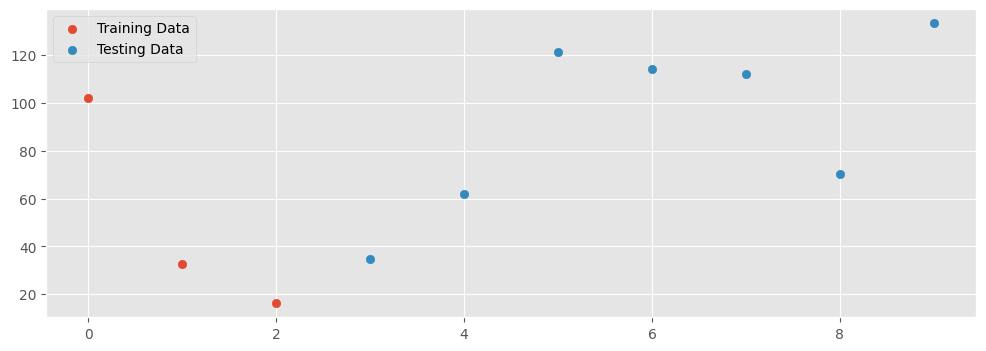

In [30]:
plt.figure(figsize=(12,4))

plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data', color='C0')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Testing Data', color='C1')

plt.legend()
plt.show()

In [31]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_ls = lr.predict(X)

In [32]:
preds:dict = {}
delta = [0.001,0.01,0.1,1,10,100]

for i in delta:
    eln = ElasticNet(alpha=i,l1_ratio=.6)
    eln.fit(X_train,y_train)
    y_pred = eln.predict(X)
    preds[f'Lambda {i}'] = y_pred

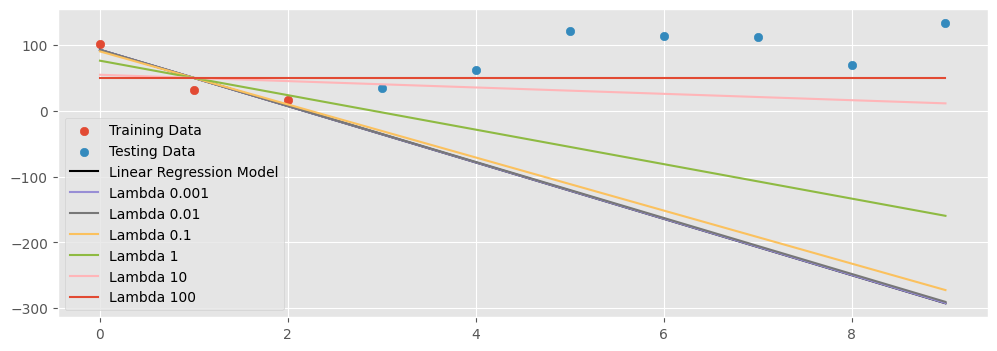

In [33]:
plt.figure(figsize=(12,4))

plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data', color='C0')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Testing Data', color='C1')

sns.lineplot(x=X.ravel(),y=y_pred_ls.ravel(), label='Linear Regression Model', color=(0,0,0,1))
for i, key in enumerate(preds.keys()):
    sns.lineplot(x=X.ravel(),y=preds[key], label=key, color=f'C{i+2}')

plt.legend()
plt.show()

## Impact on Coeficents

In [34]:
X,y = load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.5)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((221, 10), (221,), (221, 10), (221,))

In [35]:
delta = [0.001,0.01,0.1,1,10,100]
df = pd.DataFrame(columns=['β1','β2','β3','β4','β5','β6','β7','β8','β9','β10'])
for i in delta:
    eln = ElasticNet(alpha=i, l1_ratio=.4)
    eln.fit(X_train,y_train)
    df.loc[i] = eln.coef_
df

,β1,β2,β3,β4,β5,β6,β7,β8,β9,β10
0.001,-12.083842,-143.817264,492.787219,265.517118,-70.097127,-59.352692,-224.634866,146.870524,377.708715,72.224289
0.010,26.339128,-16.614247,204.192984,130.818209,9.553028,5.046674,-131.451496,103.940332,163.140103,83.223439
0.100,8.916943,2.316359,33.119750,23.525046,7.208916,7.517723,-25.258417,23.376283,28.959090,19.112381
1.000,0.478887,0.000000,2.995201,2.002745,0.327861,0.383142,-2.218919,2.080855,2.603817,1.591098
10.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
